In [1]:
import pandas as pd

df = pd.read_csv("final_dataset_2025.csv")

print(df.head())

   County Code       State            County  Good  Moderate  \
0         6005  California     Amador County   318        46   
1         6007  California      Butte County   237       128   
2         6009  California  Calaveras County   295        64   
3         6011  California     Colusa County   289        76   
4         6015  California  Del Norte County   288        64   

   Unhealthy for Sensitive Groups  Unhealthy  Very Unhealthy  Hazardous  \
0                               0          0               0          0   
1                               0          0               0          0   
2                               0          0               0          0   
3                               0          0               0          0   
4                               0          0               0          0   

   AQI Maximum  AQI 90th Percentile  AQI Median  # Days CO  # Days NO2  \
0           97                 54.0        38.0          0           0   
1           96  

In [4]:
features = [
    "Good",
    "Moderate",
    "Unhealthy for Sensitive Groups",
    "Unhealthy",
    "Very Unhealthy",
    "Hazardous",
    "AQI Maximum",
    "AQI 90th Percentile",
    "AQI Median",
    "# Days CO",
    "# Days NO2",
    "# Days O3",
    "# Days PM2.5",
    "# Days PM10"
]

X = df[features]

In [5]:
print(X.isnull().sum())

Good                              0
Moderate                          0
Unhealthy for Sensitive Groups    0
Unhealthy                         0
Very Unhealthy                    0
Hazardous                         0
AQI Maximum                       0
AQI 90th Percentile               0
AQI Median                        0
# Days CO                         0
# Days NO2                        0
# Days O3                         0
# Days PM2.5                      0
# Days PM10                       0
dtype: int64


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [8]:
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.36080068 0.17375942]
Total explained variance: 0.5345601051747174


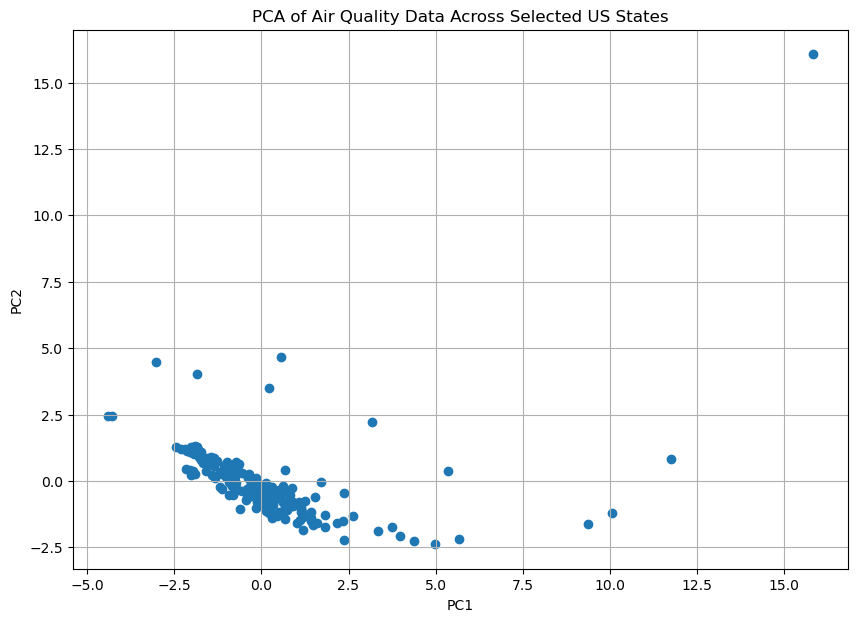

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Air Quality Data Across Selected US States")
plt.grid(True)
plt.show()

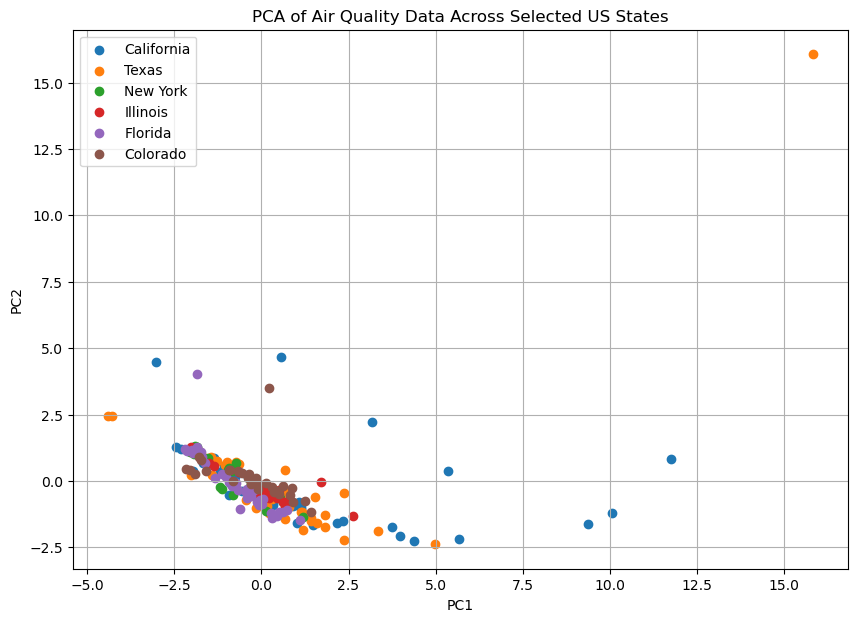

In [10]:
plt.figure(figsize=(10, 7))

for state in df["State"].unique():
    mask = df["State"] == state
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], label=state)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Air Quality Data Across Selected US States")
plt.legend()
plt.grid(True)
plt.show()

In [11]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

print(loadings)

                                     PC1       PC2
Good                           -0.326280  0.229976
Moderate                        0.343423 -0.283088
Unhealthy for Sensitive Groups  0.364392 -0.047339
Unhealthy                       0.322715  0.032424
Very Unhealthy                  0.285157  0.409391
Hazardous                       0.237143  0.469945
AQI Maximum                     0.277858  0.428649
AQI 90th Percentile             0.406049 -0.141712
AQI Median                      0.362238 -0.220550
# Days CO                       0.002109 -0.054598
# Days NO2                     -0.079158  0.096560
# Days O3                      -0.077528  0.129088
# Days PM2.5                    0.111345 -0.285865
# Days PM10                     0.056105  0.334783


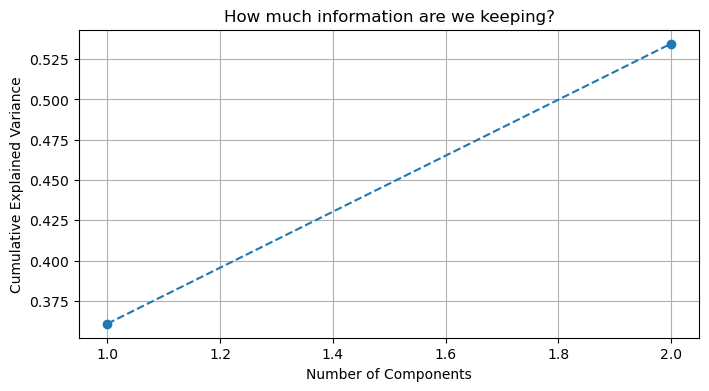

In [13]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
         np.cumsum(pca.explained_variance_ratio_), marker='o', linestyle='--')
plt.title('How much information are we keeping?')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.show()